# Homework 2 — Machine Learning for Regression

Machine Learning Zoomcamp 2026: predict car fuel efficiency in MPG.

Sources: [official assignment](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md),
[2026 dataset](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv),
and [Module 2 lecture notebook](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/02-regression/notebook.ipynb).
Instructions checked on October 6, 2026. There are six questions.

Run all cells in order with NumPy, pandas, Matplotlib, and an IPython kernel.
The CSV beside this notebook was verified against the official download (SHA-256:
`00a5cab178a8b7cd6e9157ee71dabc236ba7f20b1832336d358b07af14ba431f`).
If the local file is absent, the loading cell reads the official URL.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

print(f"NumPy: {np.__version__}; pandas: {pd.__version__}")

NumPy: 2.5.3; pandas: 3.0.6


## Data preparation and target distribution

Keep the four assigned predictors and the target. Inspect the MPG distribution.

In [2]:
data_url = (
    "https://raw.githubusercontent.com/DataTalksClub/"
    "machine-learning-zoomcamp/main/cohorts/2026/data/"
    "car_fuel_efficiency_2026.csv"
)
data_path = Path("car_fuel_efficiency_2026.csv")
features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"
columns = features + [target]

df = pd.read_csv(data_path if data_path.exists() else data_url, usecols=columns)
df = df[columns]
print(f"Rows: {len(df):,}; selected columns: {len(df.columns)}")
display(df.head())

Rows: 10,000; selected columns: 5


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


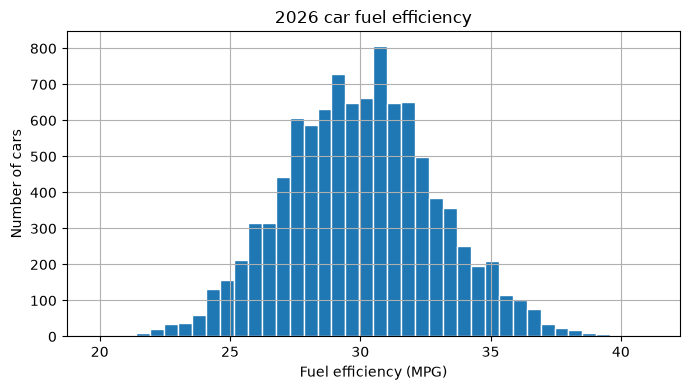

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
50%         30.000000
90%         33.800000
95%         34.905000
99%         36.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

Skewness: 0.0808


In [3]:
df[target].hist(bins=40, figsize=(7, 4), edgecolor="white")
plt.title("2026 car fuel efficiency")
plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Number of cars")
plt.tight_layout()
plt.show()

display(df[target].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print(f"Skewness: {df[target].skew():.4f}")

The distribution is approximately symmetric around 30 MPG, with skewness near zero
and no pronounced long right tail. The assignment does not request a target
transformation, so every model and RMSE below uses the original MPG values.

## Q1 — Missing values

Which selected column contains missing observations?

In [4]:
missing_counts = df.isna().sum()
display(missing_counts.to_frame("missing_values"))
missing_columns = missing_counts[missing_counts > 0].index.tolist()
q1_answer = ", ".join(missing_columns)
print("Q1:", q1_answer)

,missing_values
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


Q1: horsepower


`isna().sum()` counts missing entries column by column before any imputation.
Only horsepower needs a replacement value; all rows are retained.

## Q2 — Horsepower median

Calculate the 50th percentile before splitting.

In [5]:
q2_answer = df["horsepower"].median()
print("Q2 — median horsepower:", q2_answer)

Q2 — median horsepower: 254.0


The median is the middle observed horsepower value across the full dataset.
Pandas excludes missing entries from this calculation; they are not treated as zeros.

## Train / validation / test split

Use the lecture's shuffled 60% / 20% / 20% split with seed 42.

In [6]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(df_train), len(df_val), len(df_test)],
    "fraction": [len(df_train) / n, len(df_val) / n, len(df_test) / n],
}))

,split,rows,fraction
0,train,6000,0.6
1,validation,2000,0.2
2,test,2000,0.2


Training estimates the weights, validation compares choices, and the test set is
reserved for final evaluation. Features are selected explicitly when building
each `X`, so the target cannot become a predictor.

## Q3 — Zero versus training-mean imputation

Fit unregularized regression for each replacement. Compare validation RMSE rounded to three decimals.

In [7]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [8]:
horsepower_mean = df_train["horsepower"].mean()
print(f"Training-only mean horsepower: {horsepower_mean:.6f}")

imputation_results = []
for method, fill_value in [("With 0", 0), ("With mean", horsepower_mean)]:
    X_train = df_train[features].fillna(fill_value).values
    X_val = df_val[features].fillna(fill_value).values
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    imputation_results.append({
        "method": method,
        "validation_rmse": score,
        "rmse_3dp": round(score, 3),
    })

q3_results = pd.DataFrame(imputation_results)
display(q3_results)
best_methods = q3_results.loc[
    q3_results["rmse_3dp"] == q3_results["rmse_3dp"].min(), "method"
].tolist()
q3_answer = best_methods[0] if len(best_methods) == 1 else "Both are equally good"
print("Q3:", q3_answer)

Training-only mean horsepower: 254.463383


,method,validation_rmse,rmse_3dp
0,With 0,2.205293,2.205
1,With mean,2.201817,2.202


Q3: With mean


The lecture helper adds an intercept and fits weights through the normal equation.
RMSE is the square root of the average squared prediction error; lower is better.
The mean replacement is learned only from training rows and reused for validation,
avoiding information leakage. Both raw and rounded errors are shown above.

## Q4 — Regularization

Use zero imputation and the assigned `r` grid. Compare four-decimal validation RMSE;
break ties with the smallest `r`.

In [9]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]


X_train = df_train[features].fillna(0).values
X_val = df_val[features].fillna(0).values
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
regularization_results = []

for r in r_values:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    regularization_results.append({
        "r": r,
        "validation_rmse": score,
        "rmse_4dp": round(score, 4),
    })

q4_results = pd.DataFrame(regularization_results)
display(q4_results)
q4_answer = q4_results.loc[
    q4_results["rmse_4dp"] == q4_results["rmse_4dp"].min(), "r"
].min()
print("Q4 — best r:", q4_answer)

,r,validation_rmse,rmse_4dp
0,0.00,2.205293,2.2053
1,0.01,2.205828,2.2058
2,0.10,2.224143,2.2241
3,1.00,2.349229,2.3492
4,5.00,2.409380,2.4094
5,10.00,2.419470,2.4195
6,100.00,2.429202,2.4292


Q4 — best r: 0.0


Regularization adds `r` to the diagonal of the feature cross-product matrix.
This follows the lecture helper, including its treatment of the intercept.
The split and imputation stay fixed, so this table isolates the effect of `r`.
Selection uses the displayed four-decimal scores and the required tie rule.

## Q5 — Sensitivity to the split seed

Repeat the split for seeds 0–9, using zeros and unregularized regression.
Calculate `np.std` of validation RMSEs and round to three decimals.

In [10]:
seed_results = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train_seed = df.iloc[idx[:n_train]]
    df_val_seed = df.iloc[idx[n_train:n_train + n_val]]
    df_test_seed = df.iloc[idx[n_train + n_val:]]

    X_train_seed = df_train_seed[features].fillna(0).values
    X_val_seed = df_val_seed[features].fillna(0).values
    y_train_seed = df_train_seed[target].values
    y_val_seed = df_val_seed[target].values

    w0, w = train_linear_regression(X_train_seed, y_train_seed)
    y_pred = w0 + X_val_seed.dot(w)
    score = rmse(y_val_seed, y_pred)
    seed_results.append({"seed": seed, "validation_rmse": score})

q5_results = pd.DataFrame(seed_results)
display(q5_results)
rmse_std = np.std(q5_results["validation_rmse"].values)
q5_answer = round(rmse_std, 3)
print(f"Standard deviation (unrounded): {rmse_std:.9f}")
print("Q5 — standard deviation (3 decimals):", q5_answer)

,seed,validation_rmse
0,0,2.239204
1,1,2.202113
2,2,2.163420
3,3,2.204359
4,4,2.201880
5,5,2.245785
6,6,2.269721
7,7,2.190795
8,8,2.216611
9,9,2.207037


Standard deviation (unrounded): 0.028781274
Q5 — standard deviation (3 decimals): 0.029


Each iteration shuffles a fresh index array over the original row order.
The standard deviation uses the ten unrounded scores and NumPy's default
`ddof=0`. It measures how much validation error changes with the random split,
rather than uncertainty in individual predictions.

## Q6 — Final test evaluation

Split with seed 9, join training and validation, fill with zeros, and fit with `r=0.001`.
Evaluate test RMSE.

In [11]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_final = df.iloc[idx[:n_train]]
df_val_final = df.iloc[idx[n_train:n_train + n_val]]
df_test_final = df.iloc[idx[n_train + n_val:]]
df_full_train = pd.concat([df_train_final, df_val_final])

X_full_train = df_full_train[features].fillna(0).values
y_full_train = df_full_train[target].values
X_test = df_test_final[features].fillna(0).values
y_test_final = df_test_final[target].values

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)
q6_rmse = rmse(y_test_final, y_pred)
q6_answer = round(q6_rmse, 3)

print(f"Combined training rows: {len(df_full_train):,}")
print(f"Test rows: {len(df_test_final):,}")
print(f"Test RMSE (MPG): {q6_rmse:.9f}")
print("Q6 — test RMSE (3 decimals):", q6_answer)

Combined training rows: 8,000
Test rows: 2,000
Test RMSE (MPG): 2.235827747
Q6 — test RMSE (3 decimals): 2.236


The final model learns from 8,000 rows and is evaluated on the remaining 2,000.
No test observations enter training. The unrounded error is preserved above;
three-decimal formatting allows comparison with the matching answer option.

## Calculated answer summary

Every entry below comes from an earlier computation. No answer choices are used
as substitutes for calculations.

In [12]:
summary = pd.DataFrame([
    {"question": "Q1", "calculation": "Column with missing values", "answer": q1_answer},
    {"question": "Q2", "calculation": "Median horsepower", "answer": q2_answer},
    {"question": "Q3", "calculation": "Better imputation (RMSE, 3 dp)", "answer": q3_answer},
    {"question": "Q4", "calculation": "Best r (RMSE, 4 dp; smallest r for ties)", "answer": q4_answer},
    {"question": "Q5", "calculation": "Validation RMSE standard deviation (3 dp)", "answer": q5_answer},
    {"question": "Q6", "calculation": "Final test RMSE in MPG (3 dp)", "answer": q6_answer},
])
display(summary.set_index("question"))

,calculation,answer
question,,
Q1,Column with missing values,horsepower
Q2,Median horsepower,254.0
Q3,"Better imputation (RMSE, 3 dp)",With mean
Q4,"Best r (RMSE, 4 dp; smallest r for ties)",0.0
Q5,Validation RMSE standard deviation (3 dp),0.029
Q6,Final test RMSE in MPG (3 dp),2.236
